# Spaceship Titanic Dataset with TensorFlow Decision Forests

# Import the library

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras import layers, models
from sklearn.model_selection import KFold

# Load the Dataset

In [2]:
# Load a dataset into a Pandas Dataframe
df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
print("Full train dataset shape is {}".format(df.shape))
print("Full test dataset shape is {}".format(test_df.shape))

Full train dataset shape is (8693, 14)
Full test dataset shape is (4277, 13)


# Prepare the dataset

We will drop both `PassengerId` and `Name` columns as they are not necessary for model training.

In [3]:
df = df.drop(['PassengerId', 'Name'], axis=1)
df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported
0,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,False
1,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,True
2,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False
3,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False
4,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,True


In [4]:
test_df = test_df.drop(['PassengerId', 'Name'], axis=1)
test_df.head(5)

,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
0,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0
1,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0
2,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0
3,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0
4,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0


We will check for the missing values using the following code:

In [5]:
df.isnull().sum().sort_values(ascending=False)

CryoSleep       217
ShoppingMall    208
VIP             203
HomePlanet      201
Cabin           199
VRDeck          188
Spa             183
FoodCourt       183
Destination     182
RoomService     181
Age             179
Transported       0
dtype: int64

In [6]:
test_df.isnull().sum().sort_values(ascending=False)

FoodCourt       106
Spa             101
Cabin           100
ShoppingMall     98
CryoSleep        93
VIP              93
Destination      92
Age              91
HomePlanet       87
RoomService      82
VRDeck           80
dtype: int64

This dataset contains a mix of numeric, categorical and missing features. TF-DF supports all these feature types natively, and no preprocessing is required.

But this datatset also has boolean fields with missing values. TF-DF doesn't support boolean fields yet. So we need to convert those fields into int. To account for the missing values in the boolean fields, we will replace them with zero.

In this notebook, we will replace null value entries with zero for numerical columns as well and only let TF-DF handle the missing values in categorical columns.

Note: You can choose to let TF-DF handle missing values in numerical columns if need be.

In [7]:
df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']] = df[['VIP', 'CryoSleep', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].fillna(value=0)
df.isnull().sum().sort_values(ascending=False)

HomePlanet      201
Cabin           199
Destination     182
RoomService     181
Age             179
CryoSleep         0
VIP               0
FoodCourt         0
ShoppingMall      0
Spa               0
VRDeck            0
Transported       0
dtype: int64

Since, TF-DF cannot handle boolean columns, we will have to adjust the labels in column `Transported` to convert them into the integer format that TF-DF expects.

In [8]:
label = "Transported"
df[label] = df[label].astype(int)

We will also convert the boolean fields `CryoSleep` and `VIP` to int.

In [9]:
df['VIP'] = df['VIP'].astype(int)


The value of column `Cabin` is a string with the format `Deck/Cabin_num/Side`. Here we will split the `Cabin` column and create 3 new columns `Deck`, `Cabin_num` and `Side`, since it will be easier to train the model on those individual data.

Run the following command to split the column `Cabin` into columns `Deck`, `Cabin_num` and `Side`

In [10]:
df[["Deck", "Cabin_num", "Side"]] = df["Cabin"].str.split("/", expand=True)

Remove original `Cabin` column from the dataset since it's not needed anymore.

In [11]:
try:
    df = df.drop('Cabin', axis=1)
except KeyError:
    print("Field does not exist")

Let us display the first 5 examples from the prepared dataset.

In [12]:
df.head(5)

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Deck,Cabin_num,Side
0,Europa,False,TRAPPIST-1e,39.0,0,0.0,0.0,0.0,0.0,0.0,0,B,0,P
1,Earth,False,TRAPPIST-1e,24.0,0,109.0,9.0,25.0,549.0,44.0,1,F,0,S
2,Europa,False,TRAPPIST-1e,58.0,1,43.0,3576.0,0.0,6715.0,49.0,0,A,0,S
3,Europa,False,TRAPPIST-1e,33.0,0,0.0,1283.0,371.0,3329.0,193.0,0,A,0,S
4,Earth,False,TRAPPIST-1e,16.0,0,303.0,70.0,151.0,565.0,2.0,1,F,1,S


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HomePlanet    8492 non-null   str    
 1   CryoSleep     8693 non-null   object 
 2   Destination   8511 non-null   str    
 3   Age           8514 non-null   float64
 4   VIP           8693 non-null   int64  
 5   RoomService   8512 non-null   float64
 6   FoodCourt     8693 non-null   float64
 7   ShoppingMall  8693 non-null   float64
 8   Spa           8693 non-null   float64
 9   VRDeck        8693 non-null   float64
 10  Transported   8693 non-null   int64  
 11  Deck          8494 non-null   str    
 12  Cabin_num     8494 non-null   str    
 13  Side          8494 non-null   str    
dtypes: float64(6), int64(2), object(1), str(5)
memory usage: 950.9+ KB


In [14]:
columnas_num = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Cabin_num']

for col in columnas_num:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Tratamos numéricos con la mediana
for col in columnas_num:
    df[col] = df[col].fillna(df[col].median())

# Tratamos categóricos con la moda
columnas_cat = ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'Deck', 'Side']
for col in columnas_cat:
    # Es importante asegurar que la columna sea tratada como string para la moda
    df[col] = df[col].astype(str)
    moda = df[col].mode()[0]
    df[col] = df[col].fillna(moda)

In [15]:
# Aplicar One-Hot Encoding a las columnas categóricas
df = pd.get_dummies(df, columns=columnas_cat, drop_first=False)
df = df.astype(float)

# Verificar el resultado
print(df.head())

    Age  RoomService  FoodCourt  ShoppingMall     Spa  VRDeck  Transported  \
0  39.0          0.0        0.0           0.0     0.0     0.0          0.0   
1  24.0        109.0        9.0          25.0   549.0    44.0          1.0   
2  58.0         43.0     3576.0           0.0  6715.0    49.0          0.0   
3  33.0          0.0     1283.0         371.0  3329.0   193.0          0.0   
4  16.0        303.0       70.0         151.0   565.0     2.0          1.0   

   Cabin_num  HomePlanet_Earth  HomePlanet_Europa  ...  Deck_A  Deck_B  \
0        0.0               0.0                1.0  ...     0.0     1.0   
1        0.0               1.0                0.0  ...     0.0     0.0   
2        0.0               0.0                1.0  ...     1.0     0.0   
3        0.0               0.0                1.0  ...     1.0     0.0   
4        1.0               1.0                0.0  ...     0.0     0.0   

   Deck_C  Deck_D  Deck_E  Deck_F  Deck_G  Deck_T  Side_P  Side_S  
0     0.0     0.0 

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 29 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        8693 non-null   float64
 1   RoomService                8693 non-null   float64
 2   FoodCourt                  8693 non-null   float64
 3   ShoppingMall               8693 non-null   float64
 4   Spa                        8693 non-null   float64
 5   VRDeck                     8693 non-null   float64
 6   Transported                8693 non-null   float64
 7   Cabin_num                  8693 non-null   float64
 8   HomePlanet_Earth           8693 non-null   float64
 9   HomePlanet_Europa          8693 non-null   float64
 10  HomePlanet_Mars            8693 non-null   float64
 11  CryoSleep_0                8693 non-null   float64
 12  CryoSleep_False            8693 non-null   float64
 13  CryoSleep_True             8693 non-null   float64
 14  Des

In [17]:
def split_dataset_70_20_10(dataset):
    train_ds, temp_ds = train_test_split(dataset, test_size=0.30, random_state=42)
    valid_ds, test_ds = train_test_split(temp_ds, test_size=(1/3), random_state=42)
    return train_ds, valid_ds, test_ds



In [18]:
train_ds_pd, valid_ds_pd, test_ds_pd = split_dataset_70_20_10(df)


In [19]:
print("Train dataset shape is {}".format(train_ds_pd.shape))
print("Validation dataset shape is {}".format(valid_ds_pd.shape))   
print("Test dataset shape is {}".format(test_ds_pd.shape))


Train dataset shape is (6085, 29)
Validation dataset shape is (1738, 29)
Test dataset shape is (870, 29)


In [20]:
X_train = train_ds_pd.drop('Transported', axis=1).values
y_train = train_ds_pd['Transported'].values

X_valid = valid_ds_pd.drop('Transported', axis=1).values
y_valid = valid_ds_pd['Transported'].values

X_test = test_ds_pd.drop('Transported', axis=1).values
y_test = test_ds_pd['Transported'].values

In [21]:
scaler = StandardScaler()
# Solo 'fiteamos' con los datos de entrenamiento para evitar 'data leakage'
X_train = scaler.fit_transform(X_train)

# Usamos esa misma escala para validación y test
X_valid = scaler.transform(X_valid)
X_test = scaler.transform(X_test)

RELU

In [22]:
input_shape = X_train.shape[1] # Número de columnas actuales

model_p1 = models.Sequential([
    # Capa 1: 64 neuronas
    layers.Input(shape=(input_shape,)),
    layers.Dense(64),
    layers.Activation('relu'),       # Activación ReLU
    layers.BatchNormalization(),     # Normalización de lote (Punto 1)

    # Capa 2: 32 neuronas
    layers.Dense(32),
    layers.Activation('relu'),
    layers.BatchNormalization(),

    # Capa de Salida: 1 neurona con Sigmoid (para 0 o 1)
    layers.Dense(1, activation='sigmoid')
])

model_p1.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Ideal para clasificación binaria
    metrics=['accuracy']
)

In [23]:
# Entrenamos con un batch_size de 32 (MiniBatch)
history_p1 = model_p1.fit(
    X_train, y_train,
    epochs=30,             # Probamos con 100 iteraciones
    batch_size=32,          # Punto 6: MiniBatch
    validation_data=(X_valid, y_valid), # Usamos el 10% de validación
    verbose=1
)

Epoch 1/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.7384 - loss: 0.5043 - val_accuracy: 0.7641 - val_loss: 0.4598
Epoch 2/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7862 - loss: 0.4389 - val_accuracy: 0.7762 - val_loss: 0.4363
Epoch 3/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7921 - loss: 0.4204 - val_accuracy: 0.7641 - val_loss: 0.4413
Epoch 4/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7995 - loss: 0.4148 - val_accuracy: 0.7768 - val_loss: 0.4285
Epoch 5/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7997 - loss: 0.4139 - val_accuracy: 0.7779 - val_loss: 0.4301
Epoch 6/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.4014 - val_accuracy: 0.7865 - val_loss: 0.4207
Epoch 7/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8016 - loss: 0.4011 - val_accuracy: 0.7888 - val_loss: 0.4188
Epoch 8/30
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8082 - loss: 0.3992 - val_accuracy: 0

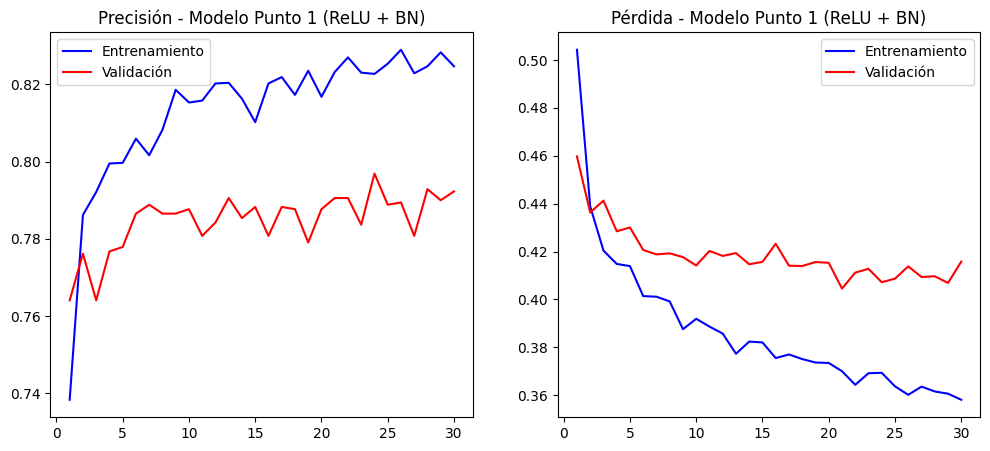

In [24]:
def plot_history(history, title):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfica de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Entrenamiento')
    plt.plot(epochs, val_acc, 'r', label='Validación')
    plt.title(f'Precisión - {title}')
    plt.legend()

    # Gráfica de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Entrenamiento')
    plt.plot(epochs, val_loss, 'r', label='Validación')
    plt.title(f'Pérdida - {title}')
    plt.legend()

    plt.show()

# Llamada a la función
plot_history(history_p1, "Modelo Punto 1 (ReLU + BN)")

LEAKY RELU

In [25]:
def build_model_p2(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Capa 1
        layers.Dense(64),
        layers.LeakyReLU(alpha=0.1), # Cambio a LeakyReLU
        layers.BatchNormalization(),
        
        # Capa 2
        layers.Dense(32),
        layers.LeakyReLU(alpha=0.1), # Cambio a LeakyReLU
        layers.BatchNormalization(),
        
        # Salida
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Crear y entrenar
model_p2 = build_model_p2(X_train.shape[1])

history_p2 = model_p2.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

Epoch 1/100


c:\Users\edufg\ml-test\.venv\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7438 - loss: 0.5165 - val_accuracy: 0.7727 - val_loss: 0.4632
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7869 - loss: 0.4402 - val_accuracy: 0.7750 - val_loss: 0.4399
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7993 - loss: 0.4244 - val_accuracy: 0.7888 - val_loss: 0.4257
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7972 - loss: 0.4221 - val_accuracy: 0.7745 - val_loss: 0.4277
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8026 - loss: 0.4171 - val_accuracy: 0.7819 - val_loss: 0.4220
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8015 - loss: 0.4155 - val_accuracy: 0.7773 - val_loss: 0.4323
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8003 - loss: 0.4096 - val_accuracy: 0.7814 - val_loss: 0.4255
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8061 - loss: 0.4072 - val_accuracy: 0.7831

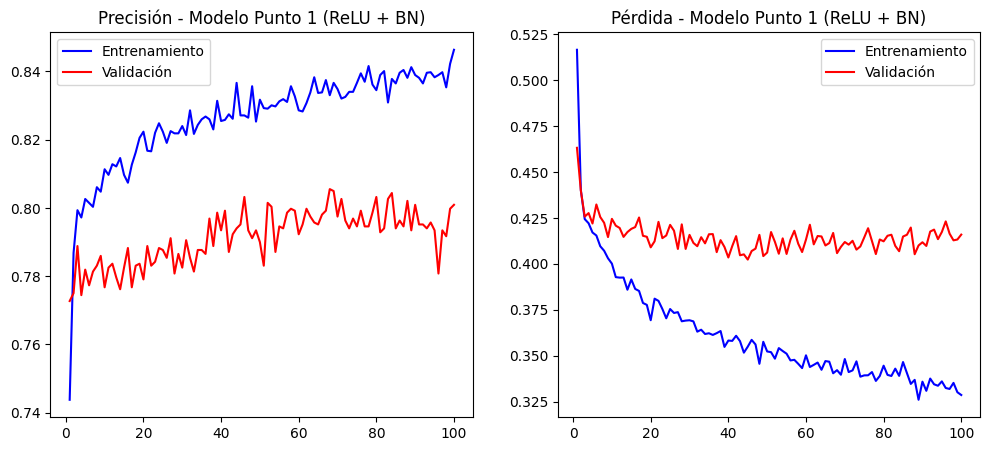

In [26]:
plot_history(history_p2, "Modelo Punto 1 (ReLU + BN)")

RELU + LEAKY RELU + BATCHNORM

In [27]:
def build_model_p3(input_dim):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        
        # Bloque 1
        layers.Dense(64),
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3), # Apaga el 30% de las neuronas en cada paso
        
        # Bloque 2
        layers.Dense(32),
        layers.Activation('relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3), # Ayuda a generalizar mejor
        
        # Salida
        layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

# Entrenamos el modelo del experimento 3
model_p3 = build_model_p3(X_train.shape[1])

history_p3 = model_p3.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_valid, y_valid),
    verbose=1
)

Epoch 1/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6740 - loss: 0.6442 - val_accuracy: 0.7560 - val_loss: 0.4798
Epoch 2/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7431 - loss: 0.5205 - val_accuracy: 0.7635 - val_loss: 0.4480
Epoch 3/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7657 - loss: 0.4820 - val_accuracy: 0.7704 - val_loss: 0.4337
Epoch 4/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7719 - loss: 0.4667 - val_accuracy: 0.7733 - val_loss: 0.4295
Epoch 5/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7811 - loss: 0.4564 - val_accuracy: 0.7716 - val_loss: 0.4275
Epoch 6/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7776 - loss: 0.4530 - val_accuracy: 0.7825 - val_loss: 0.4277
Epoch 7/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7872 - loss: 0.4399 - val_accuracy: 0.7888 - val_loss: 0.4217
Epoch 8/100
191/191 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7898 - loss: 0.4361 - val_accu

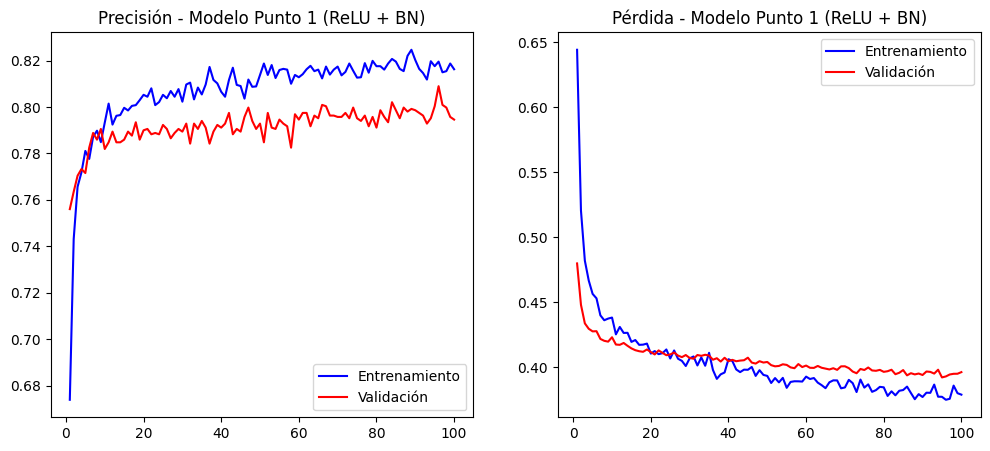

In [28]:
plot_history(history_p3, "Modelo Punto 1 (ReLU + BN)")

In [29]:
# Combinamos Train y Valid para tener un conjunto más grande (80%) para el K-Fold
X_cv = np.concatenate((X_train, X_valid), axis=0)
y_cv = np.concatenate((y_train, y_valid), axis=0)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
all_scores = []

print(f"Iniciando 5-Fold Cross Validation...")

for i, (train_index, val_index) in enumerate(kf.split(X_cv)):
    # Dividimos los datos para este "fold"
    X_train_fold, X_val_fold = X_cv[train_index], X_cv[val_index]
    y_train_fold, y_val_fold = y_cv[train_index], y_cv[val_index]
    
    # Construimos el modelo (usando la mejor arquitectura, p.ej. con Dropout)
    model = build_model_p3(X_train.shape[1]) 
    
    # Entrenamos (con menos epochs para ahorrar tiempo si prefieres)
    model.fit(
        X_train_fold, y_train_fold,
        epochs=50,
        batch_size=32,
        verbose=0 # Silenciamos para no llenar la consola
    )
    
    # Evaluamos en el set de validación de este fold
    scores = model.evaluate(X_val_fold, y_val_fold, verbose=0)
    all_scores.append(scores[1]) # Guardamos el Accuracy
    print(f"Fold {i+1} completado. Accuracy: {scores[1]:.4f}")

print(f"\nAccuracy promedio: {np.mean(all_scores):.4f} (+/- {np.std(all_scores):.4f})")

Iniciando 5-Fold Cross Validation...
Fold 1 completado. Accuracy: 0.7987
Fold 2 completado. Accuracy: 0.8115
Fold 3 completado. Accuracy: 0.8185
Fold 4 completado. Accuracy: 0.8191
Fold 5 completado. Accuracy: 0.7999

Accuracy promedio: 0.8095 (+/- 0.0088)


In [30]:
# Evaluamos el rendimiento final
final_loss, final_acc = model_p3.evaluate(X_test, y_test)
print(f"Resultado final en el set de Test (ciego): {final_acc:.4f}")

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7954 - loss: 0.3959 
Resultado final en el set de Test (ciego): 0.7954


In [31]:
# Asumiendo que guardaste los resultados de cada experimento
data = {
    "Experimento": ["P1: ReLU + BN", "P2: LeakyReLU + BN", "P3: Dropout + ReLU + BN"],
    "Accuracy Val (Máx)": [
        max(history_p1.history['val_accuracy']),
        max(history_p2.history['val_accuracy']),
        max(history_p3.history['val_accuracy'])
    ],
    "Estabilidad": ["Baja (Ruido)", "Media", "Alta (Curvas suaves)"]
}

df_comparativa = pd.DataFrame(data)
print(df_comparativa)

               Experimento  Accuracy Val (Máx)           Estabilidad
0            P1: ReLU + BN            0.796893          Baja (Ruido)
1       P2: LeakyReLU + BN            0.805524                 Media
2  P3: Dropout + ReLU + BN            0.808976  Alta (Curvas suaves)
